# <center>Задача 6. Обучение без учителя</center>
## <center>Кластеризация изображений лиц</center>

In [72]:

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans, DBSCAN
from sklearn.datasets import fetch_olivetti_faces
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score

%matplotlib inline
sns.set_style('whitegrid')


### Загрузка данных

In [ ]:

faces = fetch_olivetti_faces()
X = faces.data
y = faces.target
images = faces.images
print('Количество изображений:', X.shape[0])
print('Количество признаков:', X.shape[1])
print('Количество классов:', len(np.unique(y)))

pd.DataFrame(X)


Размер матрицы признаков: (400, 4096)
Количество изображений: 400
Количество признаков: 4096
Количество классов: 40


,0,1,2,3,4,5,6,7,8,9,...,4086,4087,4088,4089,4090,4091,4092,4093,4094,4095
0,0.309917,0.367769,0.417355,0.442149,0.528926,0.607438,0.657025,0.677686,0.690083,0.685950,...,0.665289,0.669421,0.652893,0.661157,0.475207,0.132231,0.148760,0.152893,0.161157,0.157025
1,0.454545,0.471074,0.512397,0.557851,0.595041,0.640496,0.681818,0.702479,0.710744,0.702479,...,0.136364,0.157025,0.136364,0.148760,0.152893,0.152893,0.152893,0.152893,0.152893,0.152893
2,0.318182,0.400826,0.491736,0.528926,0.586777,0.657025,0.681818,0.685950,0.702479,0.698347,...,0.074380,0.132231,0.181818,0.136364,0.128099,0.148760,0.144628,0.140496,0.148760,0.152893
3,0.198347,0.194215,0.194215,0.194215,0.190083,0.190083,0.243802,0.404959,0.483471,0.516529,...,0.652893,0.636364,0.657025,0.685950,0.727273,0.743802,0.764463,0.752066,0.752066,0.739669
4,0.500000,0.545455,0.582645,0.623967,0.648760,0.690083,0.694215,0.714876,0.723140,0.731405,...,0.190083,0.161157,0.177686,0.173554,0.177686,0.177686,0.177686,0.177686,0.173554,0.173554
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,0.400826,0.495868,0.570248,0.632231,0.648760,0.640496,0.661157,0.636364,0.665289,0.698347,...,0.388430,0.396694,0.264463,0.099174,0.181818,0.243802,0.247934,0.161157,0.157025,0.136364
396,0.367769,0.367769,0.351240,0.301653,0.247934,0.247934,0.367769,0.512397,0.574380,0.628099,...,0.380165,0.334711,0.289256,0.285124,0.338843,0.404959,0.458678,0.487603,0.512397,0.549587
397,0.500000,0.533058,0.607438,0.628099,0.657025,0.632231,0.657025,0.669421,0.673554,0.702479,...,0.194215,0.148760,0.152893,0.161157,0.161157,0.173554,0.157025,0.177686,0.148760,0.190083
398,0.214876,0.219008,0.219008,0.223140,0.210744,0.202479,0.276859,0.400826,0.487603,0.549587,...,0.446281,0.392562,0.367769,0.409091,0.479339,0.524793,0.545455,0.574380,0.590909,0.603306


### EDA

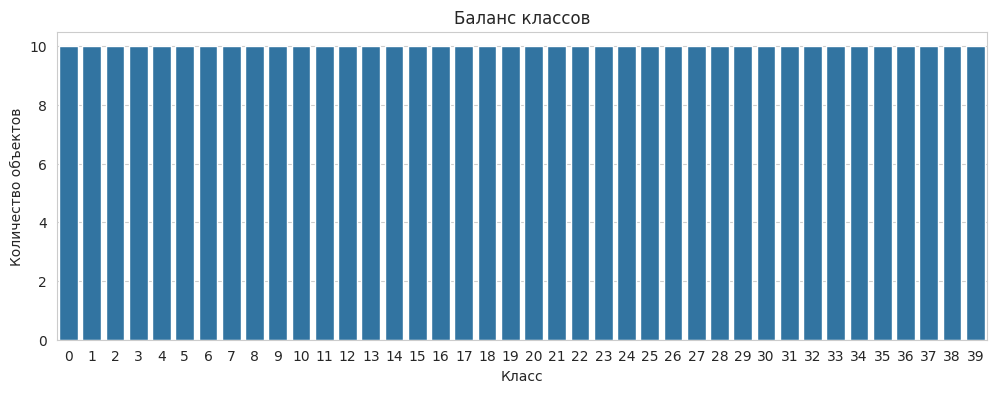

In [74]:

plt.figure(figsize=(12, 4))
sns.countplot(x=y)
plt.title('Баланс классов')
plt.xlabel('Класс')
plt.ylabel('Количество объектов')
plt.show()


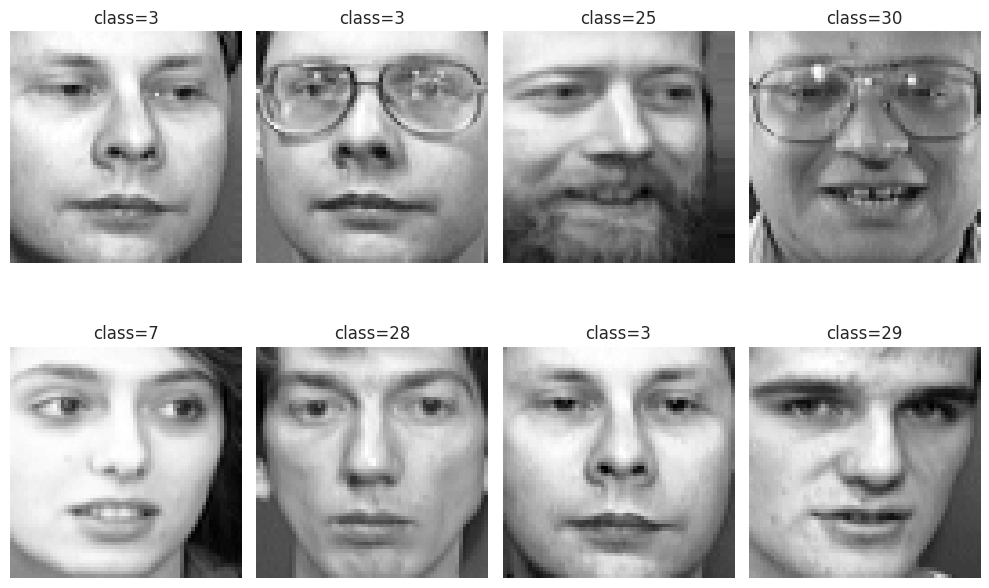

In [75]:

fig, axes = plt.subplots(2, 4, figsize=(10, 7))

indices = np.random.default_rng(42).choice(len(faces.images), size=15, replace=False)

for ax, idx in zip(axes.ravel(), indices):
    ax.imshow(faces.images[idx], cmap="gray")
    ax.set_title(f"class={y[idx]}")
    ax.axis("off")

plt.tight_layout()
plt.show()


In [76]:

print('Минимальное значение признака:', X.min())
print('Максимальное значение признака:', X.max())
print('Среднее значение признака:', X.mean())


Минимальное значение признака: 0.0
Максимальное значение признака: 1.0
Среднее значение признака: 0.5470425



**Промежуточный вывод:**

- данные уже приведены к диапазону значений от 0 до 1;
- классы сбалансированы: для каждого человека по 10 изображений;
- размерность очень большая, поэтому далее имеет смысл проверить `PCA`.


### Центрирование данных

In [77]:

X_centered = X - X.mean(axis=0)

print('Размер X:', X.shape)
print('Размер X_centered:', X_centered.shape)


Размер X: (400, 4096)
Размер X_centered: (400, 4096)


### Собственная реализация K-Means

In [78]:
class MyMeans:
    def __init__(
        self,
        n_clusters=40,
        max_iter=300,
        tol=1e-4,
        random_state=None,
        n_init=10,
    ):
        self.n_clusters = n_clusters
        self.max_iter = max_iter
        self.tol = tol
        self.random_state = random_state
        self.n_init = n_init

        self.cluster_centers_ = None
        self.labels_ = None
        self.score_ = None
        self.n_iter_ = None

    def _init_centers_kmeanspp(self, X, rng):
        n_samples, n_features = X.shape
        centers = np.empty((self.n_clusters, n_features), dtype=X.dtype)
        first_idx = rng.integers(0, n_samples)
        centers[0] = X[first_idx]

        for k in range(1, self.n_clusters):
            distances = self._compute_distances(X, centers[:k])
            min_dist_sq = np.min(distances, axis=1)

            total = np.sum(min_dist_sq)
            if total == 0:
                next_idx = rng.integers(0, n_samples)
            else:
                probs = min_dist_sq / total
                next_idx = rng.choice(n_samples, p=probs)

            centers[k] = X[next_idx]

        return centers

    def _compute_distances(self, X, centers):
        return np.sum((X[:, np.newaxis, :] - centers[np.newaxis, :, :]) ** 2, axis=2)

    def _assign_labels(self, X, centers):
        distances = self._compute_distances(X, centers)
        return np.argmin(distances, axis=1)

    def _update_centers(self, X, labels, rng):
        new_centers = np.zeros((self.n_clusters, X.shape[1]), dtype=X.dtype)

        for k in range(self.n_clusters):
            cluster_points = X[labels == k]

            if len(cluster_points) == 0:
                random_idx = rng.integers(0, X.shape[0])
                new_centers[k] = X[random_idx]
            else:
                new_centers[k] = cluster_points.mean(axis=0)

        return new_centers

    def _compute_score(self, X, centers, labels):
        return np.sum((X - centers[labels]) ** 2)

    def fit(self, X):
        X = np.asarray(X, dtype=float)
        rng = np.random.default_rng(self.random_state)

        best_score = np.inf
        best_centers = None
        best_labels = None
        best_n_iter = None

        for _ in range(self.n_init):
            centers = self._init_centers_kmeanspp(X, rng)

            for iteration in range(1, self.max_iter + 1):
                labels = self._assign_labels(X, centers)
                new_centers = self._update_centers(X, labels, rng)

                center_shift = np.linalg.norm(new_centers - centers, axis=1).max()
                centers = new_centers

                if center_shift < self.tol:
                    break

            labels = self._assign_labels(X, centers) #mb remove?
            score = self._compute_score(X, centers, labels)

            if score < best_score:
                best_score = score
                best_centers = centers.copy()
                best_labels = labels.copy()
                best_n_iter = iteration

        self.cluster_centers_ = best_centers
        self.labels_ = best_labels
        self.score_ = best_score
        self.n_iter_ = best_n_iter

        return self

    def predict(self, X):
        X = np.asarray(X, dtype=float)
        return self._assign_labels(X, self.cluster_centers_)

    def fit_predict(self, X):
        self.fit(X)
        return self.labels_


### Функция оценки качества

In [79]:

def clustering_report(X, labels):
    unique_labels = np.unique(labels)
    n_clusters = len(unique_labels) - (1 if -1 in unique_labels else 0)

    result = {
        'n_clusters_found': n_clusters,
        'silhouette': np.nan,
    }

    if n_clusters >= 2:
        mask = labels != -1
        if mask.sum() > n_clusters:
            result['silhouette'] = silhouette_score(X[mask], labels[mask])

    return result


### Обучение моделей на исходных данных

In [80]:

my_results = []
for n_clusters in [20, 30, 40, 50]:
    model = MyMeans(n_clusters=n_clusters, max_iter=100, n_init=5, random_state=42)

    start = time.perf_counter()
    labels = model.fit_predict(X_centered)
    fit_time = time.perf_counter() - start

    info = clustering_report(X_centered, labels)
    my_results.append({
        'model': 'MyMeans',
        'params': 'n_clusters={}'.format(n_clusters),
        'fit_time': fit_time,
        **info,
    })

my_results = pd.DataFrame(my_results)
my_results


,model,params,fit_time,n_clusters_found,silhouette
0,MyMeans,n_clusters=20,25.513343,20,0.102755
1,MyMeans,n_clusters=30,46.334723,30,0.117535
2,MyMeans,n_clusters=40,79.536546,40,0.119410
3,MyMeans,n_clusters=50,110.878666,50,0.150951


In [81]:

kmeans_results = []
for n_clusters in [20, 30, 40, 50]:
    model = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)

    start = time.perf_counter()
    labels = model.fit_predict(X_centered)
    fit_time = time.perf_counter() - start

    info = clustering_report(X_centered, labels)
    kmeans_results.append({
        'model': 'KMeans',
        'params': 'n_clusters={}'.format(n_clusters),
        'fit_time': fit_time,
        **info,
    })

kmeans_results = pd.DataFrame(kmeans_results)
kmeans_results


,model,params,fit_time,n_clusters_found,silhouette
0,KMeans,n_clusters=20,3.318003,20,0.113945
1,KMeans,n_clusters=30,4.325609,30,0.123791
2,KMeans,n_clusters=40,5.179234,40,0.146470
3,KMeans,n_clusters=50,6.273653,50,0.157684


In [82]:

dbscan_results = []
for eps in [8, 10, 12, 15]:
    for min_samples in [3, 5, 10]:
        model = DBSCAN(eps=eps, min_samples=min_samples)

        start = time.perf_counter()
        labels = model.fit_predict(X_centered)
        fit_time = time.perf_counter() - start

        info = clustering_report(X_centered, labels)
        dbscan_results.append({
            'model': 'DBSCAN',
            'params': 'eps={}, min_samples={}'.format(eps, min_samples),
            'fit_time': fit_time,
            **info,
        })

dbscan_results = pd.DataFrame(dbscan_results)
dbscan_results.sort_values('silhouette', ascending=False).head()


,model,params,fit_time,n_clusters_found,silhouette
1,DBSCAN,"eps=8, min_samples=5",0.365585,7,0.049870
2,DBSCAN,"eps=8, min_samples=10",0.372498,3,-0.009629
0,DBSCAN,"eps=8, min_samples=3",0.399947,16,-0.011147
3,DBSCAN,"eps=10, min_samples=3",0.316429,1,NaN
4,DBSCAN,"eps=10, min_samples=5",0.422554,1,NaN


In [83]:

all_results = pd.concat([my_results, kmeans_results, dbscan_results], ignore_index=True)
all_results = all_results.sort_values('silhouette', ascending=False).reset_index(drop=True)
all_results


,model,params,fit_time,n_clusters_found,silhouette
0,KMeans,n_clusters=50,6.273653,50,0.157684
1,MyMeans,n_clusters=50,110.878666,50,0.150951
2,KMeans,n_clusters=40,5.179234,40,0.146470
3,KMeans,n_clusters=30,4.325609,30,0.123791
4,MyMeans,n_clusters=40,79.536546,40,0.119410
5,MyMeans,n_clusters=30,46.334723,30,0.117535
6,KMeans,n_clusters=20,3.318003,20,0.113945
7,MyMeans,n_clusters=20,25.513343,20,0.102755
8,DBSCAN,"eps=8, min_samples=5",0.365585,7,0.049870
9,DBSCAN,"eps=8, min_samples=10",0.372498,3,-0.009629


In [84]:

best_my = my_results.sort_values('silhouette', ascending=False).iloc[0]
best_kmeans = kmeans_results.sort_values('silhouette', ascending=False).iloc[0]
best_dbscan = dbscan_results.sort_values('silhouette', ascending=False).iloc[0]

best_models = pd.DataFrame([best_my, best_kmeans, best_dbscan]).reset_index(drop=True)
best_models


,model,params,fit_time,n_clusters_found,silhouette
0,MyMeans,n_clusters=50,110.878666,50,0.150951
1,KMeans,n_clusters=50,6.273653,50,0.157684
2,DBSCAN,"eps=8, min_samples=5",0.365585,7,0.049870


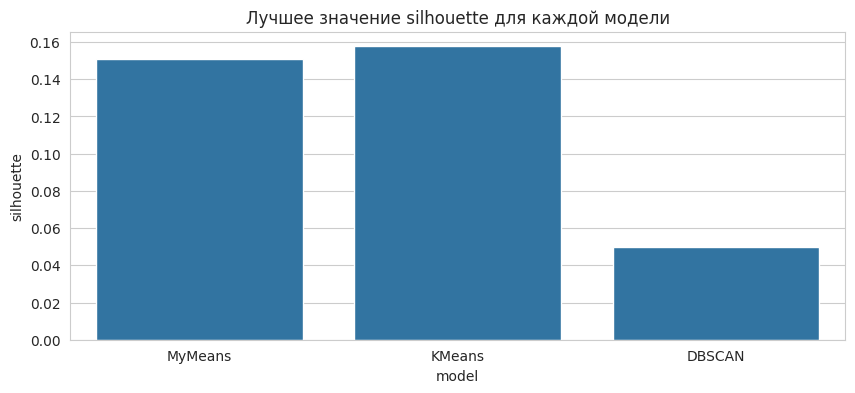

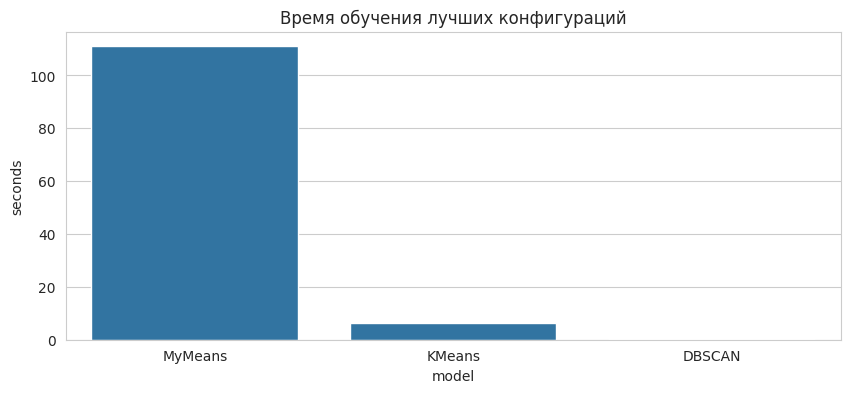

In [85]:

plt.figure(figsize=(10, 4))
sns.barplot(data=best_models, x='model', y='silhouette')
plt.title('Лучшее значение silhouette для каждой модели')
plt.ylabel('silhouette')
plt.show()

plt.figure(figsize=(10, 4))
sns.barplot(data=best_models, x='model', y='fit_time')
plt.title('Время обучения лучших конфигураций')
plt.ylabel('seconds')
plt.show()



**Вывод по исходным данным:**

На исходных данных лучший результат по `silhouette` показал `KMeans`. Собственная реализация `MyMeans` дала близкое качество, но работала значительно дольше. `DBSCAN` обучился быстро, однако качество кластеризации оказалось заметно хуже. Поэтому до применения PCA наиболее удачным методом на этих данных является KMeans.


### PCA

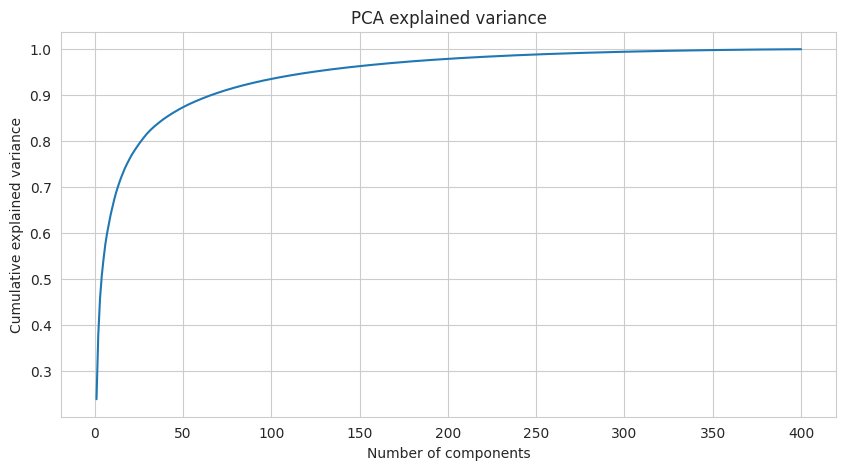

In [86]:

pca_full = PCA(random_state=42)
X_pca_full = pca_full.fit_transform(X_centered)

cum_var = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(10, 5))
plt.plot(np.arange(1, len(cum_var) + 1), cum_var)
plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance")
plt.title("PCA explained variance")
plt.show()


In [87]:

pca_results = []

for n_comp in [10, 20, 40, 80, 120]:
    pca = PCA(n_components=n_comp, random_state=42)
    X_pca = pca.fit_transform(X_centered)

    for n_clusters in [20, 30, 40, 50]:
        model = MyMeans(n_clusters=n_clusters, max_iter=100, n_init=5, random_state=42)
        start = time.perf_counter()
        labels = model.fit_predict(X_pca)
        fit_time = time.perf_counter() - start
        info = clustering_report(X_pca, labels)
        pca_results.append({
            'model': 'MyMeans',
            'pca_components': n_comp,
            'params': 'n_clusters={}'.format(n_clusters),
            'fit_time': fit_time,
            **info,
        })

    for n_clusters in [20, 30, 40, 50]:
        model = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
        start = time.perf_counter()
        labels = model.fit_predict(X_pca)
        fit_time = time.perf_counter() - start
        info = clustering_report(X_pca, labels)
        pca_results.append({
            'model': 'KMeans',
            'pca_components': n_comp,
            'params': 'n_clusters={}'.format(n_clusters),
            'fit_time': fit_time,
            **info,
        })

    for eps in [8, 10, 12, 15]:
        for min_samples in [3, 5, 10]:
            model = DBSCAN(eps=eps, min_samples=min_samples)
            start = time.perf_counter()
            labels = model.fit_predict(X_pca)
            fit_time = time.perf_counter() - start
            info = clustering_report(X_pca, labels)
            pca_results.append({
                'model': 'DBSCAN',
                'pca_components': n_comp,
                'params': 'eps={}, min_samples={}'.format(eps, min_samples),
                'fit_time': fit_time,
                **info,
            })

pca_results = pd.DataFrame(pca_results)



In [88]:

best_pca_results = (
    pca_results
    .sort_values('silhouette', ascending=False)
    .groupby(['model', 'pca_components'], as_index=False)
    .first()
    .sort_values(['model', 'pca_components'])
    .reset_index(drop=True)
)

best_pca_results


,model,pca_components,params,fit_time,n_clusters_found,silhouette
0,DBSCAN,10,"eps=8, min_samples=3",0.041927,1,NaN
1,DBSCAN,20,"eps=8, min_samples=3",0.065382,1,NaN
2,DBSCAN,40,"eps=8, min_samples=5",0.052171,2,0.065182
3,DBSCAN,80,"eps=8, min_samples=10",0.079752,2,0.176107
4,DBSCAN,120,"eps=8, min_samples=10",0.069723,2,0.171618
5,KMeans,10,n_clusters=50,0.719359,50,0.274112
6,KMeans,20,n_clusters=50,0.585813,50,0.267102
7,KMeans,40,n_clusters=50,0.627845,50,0.234574
8,KMeans,80,n_clusters=50,1.037163,50,0.216206
9,KMeans,120,n_clusters=50,0.669563,50,0.188424


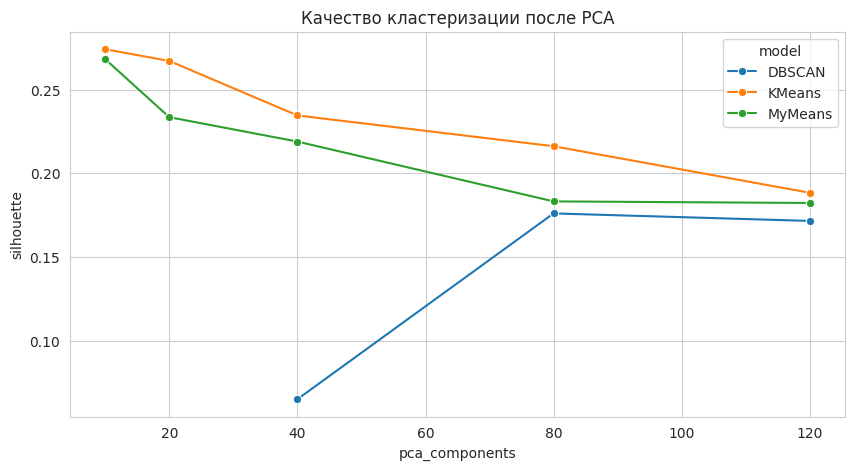

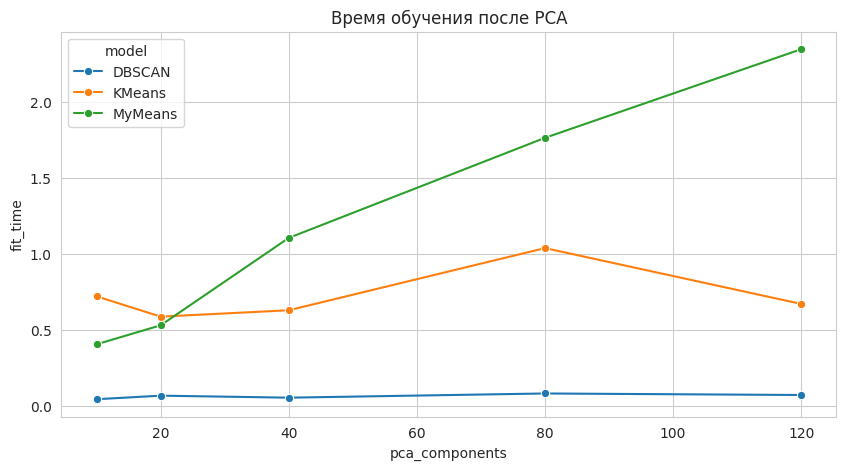

In [89]:

plt.figure(figsize=(10, 5))
sns.lineplot(data=best_pca_results, x='pca_components', y='silhouette', hue='model', marker='o')
plt.title('Качество кластеризации после PCA')
plt.show()

plt.figure(figsize=(10, 5))
sns.lineplot(data=best_pca_results, x='pca_components', y='fit_time', hue='model', marker='o')
plt.title('Время обучения после PCA')
plt.show()


In [90]:

best_pca_summary = (
    pca_results
    .sort_values('silhouette', ascending=False)
    .groupby('model', as_index=False)
    .first()
)

best_pca_summary


,model,pca_components,params,fit_time,n_clusters_found,silhouette
0,DBSCAN,80,"eps=8, min_samples=10",0.079752,2,0.176107
1,KMeans,10,n_clusters=50,0.719359,50,0.274112
2,MyMeans,10,n_clusters=50,0.403883,50,0.268131



**Вывод по PCA:**

После применения PCA качество кластеризации для методов KMeans и MyMeans заметно улучшилось по сравнению с исходным пространством признаков. Лучший результат был получен при использовании 10 главных компонент: для KMeans значение silhouette составило 0.274, а для MyMeans 0.268. Это существенно выше результатов без PCA.

При дальнейшем увеличении числа компонент качество кластеризации у KMeans и MyMeans постепенно снижалось. Это показывает, что небольшое число главных компонент позволяет сохранить наиболее полезную структуру данных и одновременно убрать шум и менее значимые признаки.

Алгоритм DBSCAN даже после PCA показал более слабые результаты. Для части конфигураций он находил только один кластер, поэтому метрика silhouette не вычислялась. В остальных случаях качество также оказалось ниже, чем у методов семейства K-Means. Следовательно, для данного набора данных DBSCAN подходит хуже.


### Визуализация данных после PCA

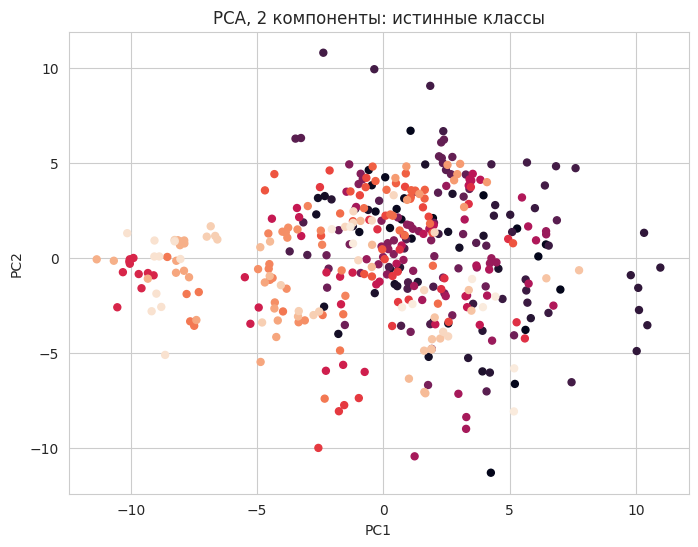

In [91]:

pca_2d = PCA(n_components=2, random_state=42)
X_2d = pca_2d.fit_transform(X_centered)

plt.figure(figsize=(8, 6))
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=y, s=25)
plt.title('PCA, 2 компоненты: истинные классы')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()


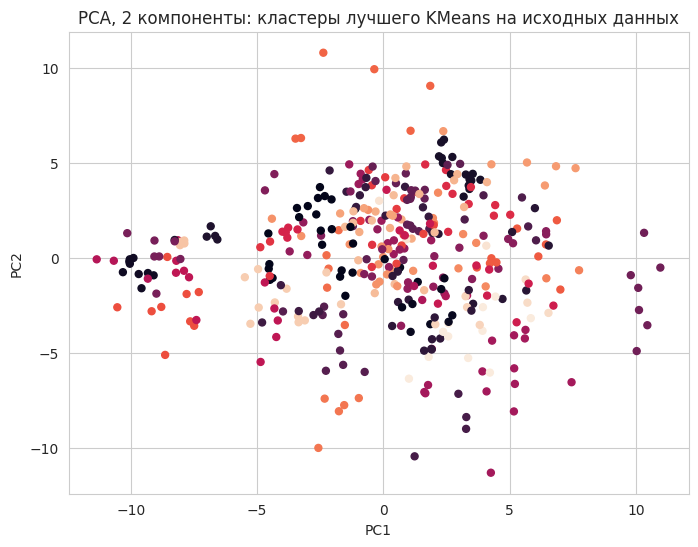

In [92]:

best_kmeans_n_clusters = int(best_kmeans['params'].split('=')[1])
best_model = KMeans(n_clusters=best_kmeans_n_clusters, random_state=42, n_init=10)
best_labels = best_model.fit_predict(X_centered)

plt.figure(figsize=(8, 6))
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=best_labels, s=25)
plt.title('PCA, 2 компоненты: кластеры лучшего KMeans на исходных данных')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()


### t-SNE

In [93]:

pca_for_tsne = PCA(n_components=30, random_state=42)
X_tsne_input = pca_for_tsne.fit_transform(X_centered)

start = time.perf_counter()
tsne = TSNE(random_state=42)
X_tsne = tsne.fit_transform(X_tsne_input)
tsne_time = time.perf_counter() - start

print('Время работы t-SNE: {:.3f} сек'.format(tsne_time))


Время работы t-SNE: 4.101 сек


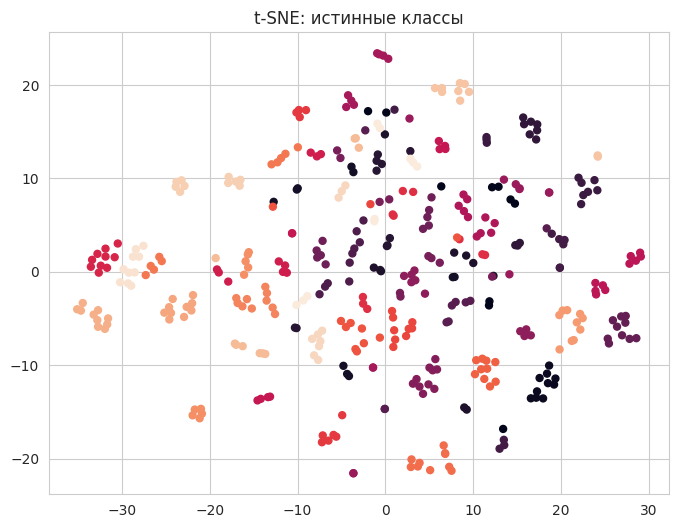

In [94]:

plt.figure(figsize=(8, 6))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y, s=25)
plt.title('t-SNE: истинные классы')
plt.show()


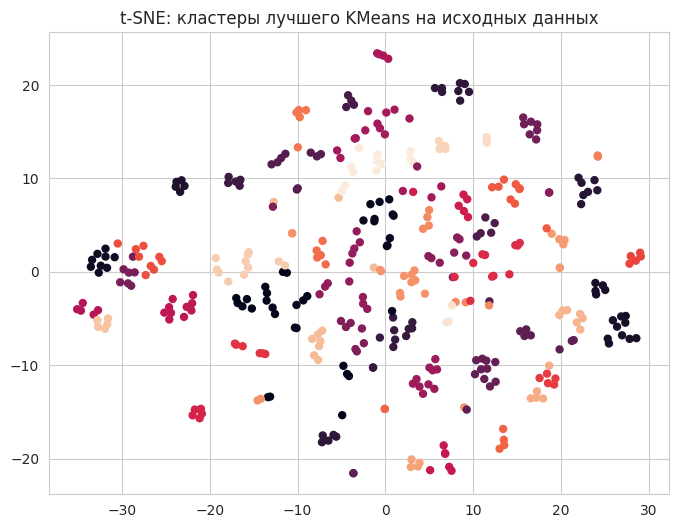

In [95]:

plt.figure(figsize=(8, 6))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=best_labels, s=25)
plt.title('t-SNE: кластеры лучшего KMeans на исходных данных')
plt.show()



**Выводы по визуализации t-SNE**

Визуализация с помощью t-SNE показала локальную структуру данных лучше, чем PCA: точки распались на множество более компактных групп. Это говорит о том, что в исходных данных действительно присутствуют локальные области сходства между объектами.

Однако даже на t-SNE истинные классы не разделяются полностью и заметно перекрываются. Следовательно, задача кластеризации на данном наборе данных является нетривиальной: объекты разных классов в признаковом пространстве частично близки друг к другу.

Сравнение визуализации истинных классов и кластеров, найденных лучшим KMeans, показывает, что алгоритм улавливает часть локальной структуры данных, но не воспроизводит истинное разбиение полностью.


### Итоговые выводы
В работе была исследована задача кластеризации многомерных данных без учителя. Были выполнены предварительный анализ данных, обучение собственной реализации KMeans (MyMeans), а также обучение библиотечных моделей KMeans и DBSCAN. Качество сравнивалось по времени обучения, числу найденных кластеров и значению silhouete.

На исходных данных лучший результат показал KMeans, собственная реализация MyMeans дала близкое качество, что подтверждает корректность реализации, однако библиотечная  версия в целом оказалась более эффективной по времени. DBSCAN на исходных признаках показал заметно худший результат.

После применения PCA качество кластеризации для KMeans и MyMeans значительно улучшилось. Наилучшие результаты были получены при небольшом числе главных компонент, особенно при 10 компонентах. Это означает, что снижение размерности оказалось полезным: оно позволило убрать часть шума, сохранив при этом наиболее важную структуру. Для DBSCAN применение PCA не привело к сопоставимому улучшению и алгоритм по прежнему выделял слишком грубую структуру и находил мало кластеров.

Визуализации с помощью PCA и t-SNE показали, что данные не распадаются на хорошо отделимые группы. Особенно это заметно по сильному перекрытию классов на плоскости. t-SNE выявил локальные группы лучше, чем PCA, однако и там не наблюдается полного разделения объектов по классам. Это согласуется с результатами кластеризации.

Низкие значения silhouette во всех экспериментах можно объяснить тем, что, вероятно, данные имеют сложную структуру: классы частично пересекаются, внутриклассовая изменчивость велика, а сами классы, вероятно, не образуют компактные и хорошо отделимые кластеры в исходном признаковом пространстве. Поэтому даже при наличии известных меток задача кластеризации здесь остается трудной, и высоких значений silhouette не получилось.

Наиболее удачным методом на данном наборе данных оказался KMeans, а наилучшее качество было достигнуто после предварительного снижения размерности с помощью PCA до небольшого числа компонент. Следовательно, для этих данных комбинация PCA + KMeans является наиболее разумным решением среди рассмотренных вариантов.